In [2]:
import joblib
import numpy as np
import pandas as pd
import optuna
X_train = joblib.load("../features/X_train.pkl")
X_val = joblib.load("../features/X_val.pkl")
X_test = joblib.load("../features/X_test.pkl")

y_train = joblib.load("../features/y_train.pkl")
y_val = joblib.load("../features/y_val.pkl")
y_test = joblib.load("../features/y_test.pkl")

print(X_train.shape)

(1134, 11)


e:\conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

np.isnan(X_train_full).sum()

np.int64(0)

In [4]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
def xgb_objective(trial):
    
    params = {
        "objective": "binary:logistic",
        "n_estimators": trial.suggest_int("n_estimators",100,800),
        "max_depth": trial.suggest_int("max_depth",3,8),
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.3),
        "subsample": trial.suggest_float("subsample",0.6,1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0),
        "gamma": trial.suggest_float("gamma",0,5),
        "min_child_weight": trial.suggest_int("min_child_weight",1,10),
        "scale_pos_weight": len(y_train_full[y_train_full == 0]) / len(y_train_full[y_train_full == 1]),
        "eval_metric": "auc",
        "n_jobs": -1,
        "random_state": 42
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    # Standard XGBoost model, no custom wrappers needed
    model = XGBClassifier(**params)
    
    # Manual Cross-Validation Loop
    for train_idx, val_idx in cv.split(X_train_full, y_train_full):
        # Depending on if your data is a Pandas DataFrame or Numpy Array:
        # Use .iloc if it's a DataFrame, or just [] if it's a NumPy array
        X_tr, X_val = X_train_full[train_idx], X_train_full[val_idx]
        y_tr, y_val = y_train_full[train_idx], y_train_full[val_idx]
        
        model.fit(X_tr, y_tr)
        
        # Get probabilities for the positive class (class 1)
        val_preds = model.predict_proba(X_val)[:, 1]
        
        # Calculate and store ROC-AUC directly
        score = roc_auc_score(y_val, val_preds)
        scores.append(score)
        
    return np.mean(scores)

In [6]:
study_xgb = optuna.create_study(direction="maximize")

study_xgb.optimize(xgb_objective, n_trials=500)

[I 2026-03-10 01:29:53,046] A new study created in memory with name: no-name-040f9034-1961-4017-8f04-8c5d5a6b53b3
[I 2026-03-10 01:29:53,351] Trial 0 finished with value: 0.8507562638583959 and parameters: {'n_estimators': 216, 'max_depth': 4, 'learning_rate': 0.06150503427641487, 'subsample': 0.6588882786468795, 'colsample_bytree': 0.9173422700972728, 'gamma': 0.9520591492921926, 'min_child_weight': 5}. Best is trial 0 with value: 0.8507562638583959.
[I 2026-03-10 01:29:53,624] Trial 1 finished with value: 0.8334503472895154 and parameters: {'n_estimators': 281, 'max_depth': 5, 'learning_rate': 0.16914475900331935, 'subsample': 0.7722711516620296, 'colsample_bytree': 0.9077312464773828, 'gamma': 1.4961349694879629, 'min_child_weight': 3}. Best is trial 0 with value: 0.8507562638583959.
[I 2026-03-10 01:29:54,049] Trial 2 finished with value: 0.7993811349365443 and parameters: {'n_estimators': 538, 'max_depth': 5, 'learning_rate': 0.2547556250307199, 'subsample': 0.6052141784654413, 'c

In [7]:
print(study_xgb.best_params)
print(study_xgb.best_value)

{'n_estimators': 112, 'max_depth': 3, 'learning_rate': 0.03997183867505357, 'subsample': 0.6670528139218452, 'colsample_bytree': 0.6265755935689993, 'gamma': 2.908505317608034, 'min_child_weight': 1}
0.8869283446803846


In [8]:
best_xgb = XGBClassifier(
    **study_xgb.best_params
)

best_xgb.fit(X_train_full,y_train_full)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6265755935689993
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [9]:
val_probs = best_xgb.predict_proba(X_val)[:,1]

In [10]:
thresholds = np.linspace(0.05,0.95,50)

results = []

for t in thresholds:
    
    preds = (val_probs >= t).astype(int)
    
    precision = precision_score(y_val,preds)
    recall = recall_score(y_val,preds)
    f1 = f1_score(y_val,preds)
    
    results.append((t,precision,recall,f1))

results = np.array(results)

e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: 

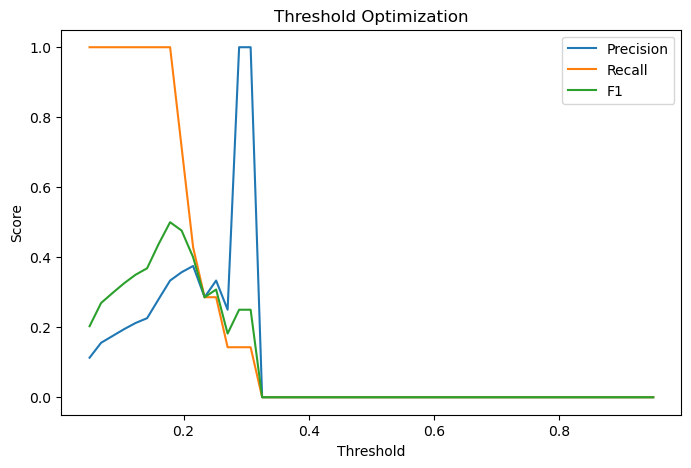

In [11]:
plt.figure(figsize=(8,5))

plt.plot(results[:,0],results[:,1],label="Precision")
plt.plot(results[:,0],results[:,2],label="Recall")
plt.plot(results[:,0],results[:,3],label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()

plt.show()

In [12]:
best_index = np.argmax(results[:,3])
best_threshold = results[best_index,0]

print("Best Threshold:",best_threshold)
print("Best F1:",results[best_index,3])

Best Threshold: 0.17857142857142855
Best F1: 0.5


In [13]:
best_threshold = float(best_threshold)

val_preds = (val_probs >= best_threshold).astype(int)

In [14]:
print("Accuracy:", accuracy_score(y_val,val_preds))
print("Precision:", precision_score(y_val,val_preds))
print("Recall:", recall_score(y_val,val_preds))
print("F1:", f1_score(y_val,val_preds))
print("ROC-AUC:", roc_auc_score(y_val,val_probs))

Accuracy: 0.9423868312757202
Precision: 0.3333333333333333
Recall: 1.0
F1: 0.5
ROC-AUC: 0.9769975786924939


In [15]:
print(classification_report(y_val,val_preds))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97       236
           1       0.33      1.00      0.50         7

    accuracy                           0.94       243
   macro avg       0.67      0.97      0.73       243
weighted avg       0.98      0.94      0.96       243



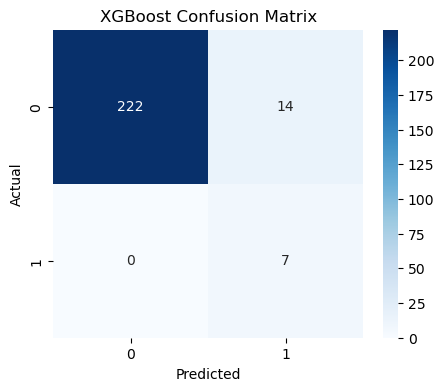

In [16]:
cm = confusion_matrix(y_val,val_preds)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

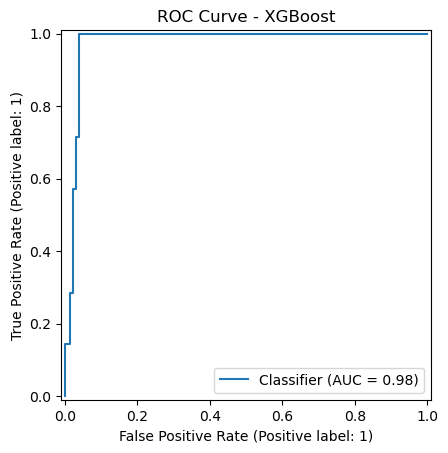

In [17]:
RocCurveDisplay.from_predictions(
    y_val,
    val_probs
)

plt.title("ROC Curve - XGBoost")

plt.show()

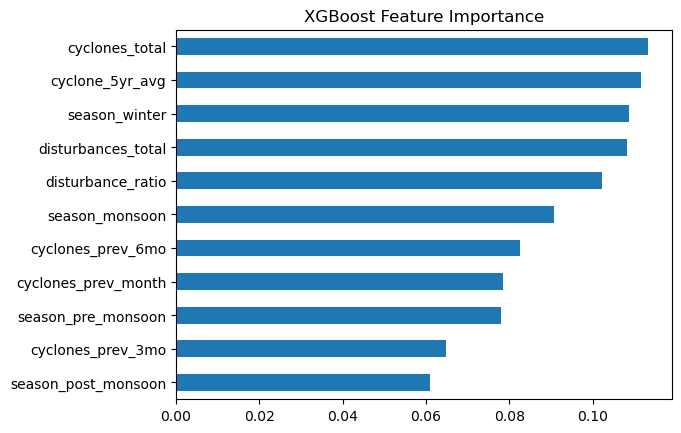

In [18]:
feature_names = [
    "cyclones_total",
    "disturbances_total",
    "disturbance_ratio",
    "cyclone_5yr_avg",
    "season_monsoon",
    "season_post_monsoon",
    "season_pre_monsoon",
    "season_winter",
    "cyclones_prev_month",
    "cyclones_prev_3mo",
    "cyclones_prev_6mo"
]

importances = pd.Series(
    best_xgb.feature_importances_,
    index=feature_names
)

importances.sort_values().plot.barh()

plt.title("XGBoost Feature Importance")

plt.show()

In [19]:
test_preds = best_xgb.predict(X_test)
test_probs = best_xgb.predict_proba(X_test)[:,1]

print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs))
print("TEST F1:", f1_score(y_test, test_preds))

TEST ROC-AUC: 0.9036182158452901
TEST F1: 0.0


In [20]:
joblib.dump(
    best_xgb,
    "../models/xgb_optuna_model.pkl"
)

['../models/xgb_optuna_model.pkl']